# Exploratory Data Analysis: Wine Reviews Dataset

### Датасет содержит отзывы о винах, включая:

- страну происхождения
- регион
- сорт винограда
- цену
- оценку вина (points)
- описание от дегустаторов

### Источник датасета:
https://www.kaggle.com/datasets/zynicide/wine-reviews

### Размер датасета:
- ~130k записей
- 14 признаков

### Цель анализа:
провести разведочный анализ данных (EDA), очистить данные, исследовать зависимости и подготовить данные для дальнейшего машинного обучения.


In [1]:
import pandas as pd

wine_df = pd.read_csv('winemag-data-130k-v2.csv', index_col=0)

wine_df.info()
wine_df.shape

<class 'pandas.DataFrame'>
RangeIndex: 129971 entries, 0 to 129970
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   country                129908 non-null  str    
 1   description            129971 non-null  str    
 2   designation            92506 non-null   str    
 3   points                 129971 non-null  int64  
 4   price                  120975 non-null  float64
 5   province               129908 non-null  str    
 6   region_1               108724 non-null  str    
 7   region_2               50511 non-null   str    
 8   taster_name            103727 non-null  str    
 9   taster_twitter_handle  98758 non-null   str    
 10  title                  129971 non-null  str    
 11  variety                129970 non-null  str    
 12  winery                 129971 non-null  str    
dtypes: float64(1), int64(1), str(11)
memory usage: 12.9 MB


(129971, 13)

В датасете 129971 строк и 14 колонок.
В датасете присутствуют:

Числовые признаки:
- points
- price

Категориальные признаки:
- country
- province
- variety
- winery
- taster_name

Также видно, что некоторые признаки имеют пропуски:
- price
- designation
- region_1
- region_2
- taster_name

In [2]:
display(wine_df.head())
display(wine_df.tail())

,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery
0,Italy,"Aromas include tropical fruit, broom, brimston...",Vulkà Bianco,87,NaN,Sicily & Sardinia,Etna,NaN,Kerin O’Keefe,@kerinokeefe,Nicosia 2013 Vulkà Bianco (Etna),White Blend,Nicosia
1,Portugal,"This is ripe and fruity, a wine that is smooth...",Avidagos,87,15.0,Douro,NaN,NaN,Roger Voss,@vossroger,Quinta dos Avidagos 2011 Avidagos Red (Douro),Portuguese Red,Quinta dos Avidagos
2,US,"Tart and snappy, the flavors of lime flesh and...",NaN,87,14.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Rainstorm 2013 Pinot Gris (Willamette Valley),Pinot Gris,Rainstorm
3,US,"Pineapple rind, lemon pith and orange blossom ...",Reserve Late Harvest,87,13.0,Michigan,Lake Michigan Shore,NaN,Alexander Peartree,NaN,St. Julian 2013 Reserve Late Harvest Riesling ...,Riesling,St. Julian
4,US,"Much like the regular bottling from 2012, this...",Vintner's Reserve Wild Child Block,87,65.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Sweet Cheeks 2012 Vintner's Reserve Wild Child...,Pinot Noir,Sweet Cheeks


,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery
129966,Germany,Notes of honeysuckle and cantaloupe sweeten th...,Brauneberger Juffer-Sonnenuhr Spätlese,90,28.0,Mosel,NaN,NaN,Anna Lee C. Iijima,NaN,Dr. H. Thanisch (Erben Müller-Burggraef) 2013 ...,Riesling,Dr. H. Thanisch (Erben Müller-Burggraef)
129967,US,Citation is given as much as a decade of bottl...,NaN,90,75.0,Oregon,Oregon,Oregon Other,Paul Gregutt,@paulgwine,Citation 2004 Pinot Noir (Oregon),Pinot Noir,Citation
129968,France,Well-drained gravel soil gives this wine its c...,Kritt,90,30.0,Alsace,Alsace,NaN,Roger Voss,@vossroger,Domaine Gresser 2013 Kritt Gewurztraminer (Als...,Gewürztraminer,Domaine Gresser
129969,France,"A dry style of Pinot Gris, this is crisp with ...",NaN,90,32.0,Alsace,Alsace,NaN,Roger Voss,@vossroger,Domaine Marcel Deiss 2012 Pinot Gris (Alsace),Pinot Gris,Domaine Marcel Deiss
129970,France,"Big, rich and off-dry, this is powered by inte...",Lieu-dit Harth Cuvée Caroline,90,21.0,Alsace,Alsace,NaN,Roger Voss,@vossroger,Domaine Schoffit 2012 Lieu-dit Harth Cuvée Car...,Gewürztraminer,Domaine Schoffit


In [3]:
wine_df.describe()

,points,price
count,129971.000000,120975.000000
mean,88.447138,35.363389
std,3.039730,41.022218
min,80.000000,4.000000
25%,86.000000,17.000000
50%,88.000000,25.000000
75%,91.000000,42.000000
max,100.000000,3300.000000


In [4]:
wine_df.describe(include=['object', 'string'])

,country,description,designation,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery
count,129908,129971,92506,129908,108724,50511,103727,98758,129971,129970,129971
unique,43,119955,37979,425,1229,17,19,15,118840,707,16757
top,US,This zesty red has pretty aromas that suggest ...,Reserve,California,Napa Valley,Central Coast,Roger Voss,@vossroger,Gloria Ferrer NV Sonoma Brut Sparkling (Sonoma...,Pinot Noir,Wines & Winemakers
freq,54504,3,2009,36247,4480,11065,25514,25514,11,13272,222


In [5]:
wine_df.isnull().sum().sort_values(ascending=False)

region_2                 79460
designation              37465
taster_twitter_handle    31213
taster_name              26244
region_1                 21247
price                     8996
province                    63
country                     63
variety                      1
points                       0
description                  0
title                        0
winery                       0
dtype: int64

Некоторые признаки имеют значительное количество пропусков:

- region_2
- designation
- taster_twitter_handle
- taster_name
- region_1
- price

Это потребует обработки на этапе очистки данных.

In [6]:
wine_df.duplicated().sum()

np.int64(9983)

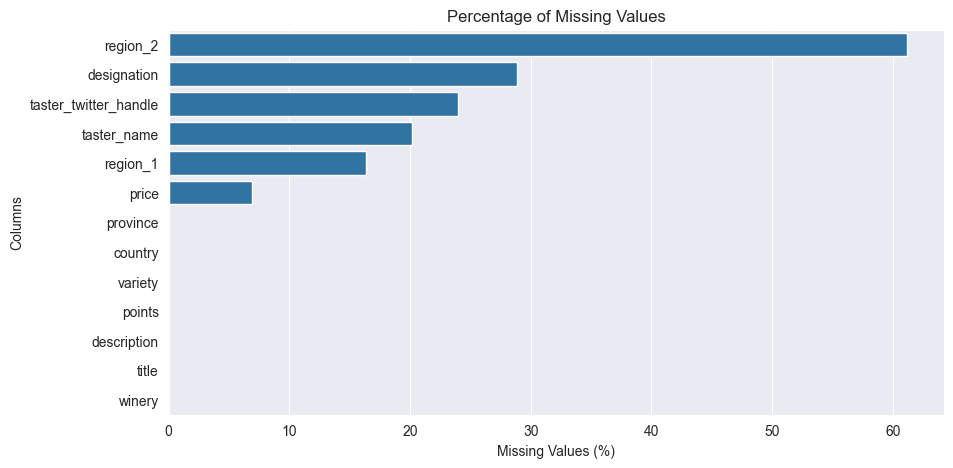

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

missing_percent = wine_df.isnull().mean().sort_values(ascending=False) * 100

plt.figure(figsize=(10,5))

sns.barplot(
    x=missing_percent.values,
    y=missing_percent.index
)

plt.title("Percentage of Missing Values")
plt.xlabel("Missing Values (%)")
plt.ylabel("Columns")

plt.show()

In [8]:
wine_df = wine_df.dropna(subset=["country", "province", "variety"])

wine_df["price"] = wine_df["price"].fillna(wine_df["price"].median())

wine_df["taster_name"] = wine_df["taster_name"].fillna("Unknown")

wine_df["taster_twitter_handle"] = wine_df["taster_twitter_handle"].fillna(
    wine_df["taster_twitter_handle"].mode()[0]
)

wine_df = wine_df.drop(columns=["region_2"])

wine_df["region_1"] = wine_df["region_1"].fillna(wine_df["region_1"].mode()[0])
wine_df["designation"] = wine_df["designation"].fillna(wine_df["designation"].mode()[0])

# Проверяем результат
wine_df.isnull().sum()

country                  0
description              0
designation              0
points                   0
price                    0
province                 0
region_1                 0
taster_name              0
taster_twitter_handle    0
title                    0
variety                  0
winery                   0
dtype: int64

Колонки `country`, `province` и `variety` содержат очень небольшое количество пропусков 
(менее 0.1% от датасета). Удаление этих строк практически не влияет на общий объем данных, 
поэтому для них была применена стратегия `dropna()`.

Колонка `price` содержит числовые значения и имеет выбросы 
(некоторые вина стоят значительно дороже остальных).
Для таких распределений медиана является более устойчивой 
оценкой центрального значения, чем среднее. Поэтому пропуски 
в колонке `price` были заполнены медианой.

Колонка `taster_name` содержит имена дегустаторов. 
Пропуски были заполнены строкой `"Unknown"`, чтобы сохранить 
данные и явно обозначить отсутствие информации о дегустаторе.

In [17]:
stats = wine_df[['price', 'points']].agg(['min', 'max', 'mean', 'median'])
stats.loc['mode'] = wine_df[['price', 'points']].mode().iloc[0]

display(stats)

quantiles = [0.05, 0.25, 0.5, 0.75, 0.95]

quantiles_df = pd.DataFrame({
    "price": wine_df["price"].quantile(quantiles),
    "points": wine_df["points"].quantile(quantiles)
})

display(quantiles_df)


stats = wine_df[['price', 'points']].agg(['var', 'skew', 'kurtosis']).T
stats.columns = ['Variance', 'Skewness', 'Kurtosis']
display(stats)

,price,points
min,4.000000,80.000000
max,3300.000000,100.000000
mean,34.651081,88.447051
median,25.000000,88.000000
mode,25.000000,88.000000


,price,points
0.05,11.0,84.0
0.25,18.0,86.0
0.50,25.0,88.0
0.75,40.0,91.0
0.95,80.0,93.0


,Variance,Skewness,Kurtosis
price,1573.950468,18.584938,884.571498
points,9.242071,0.046095,-0.296326


## Интерпретация дисперсии, асимметрии и эксцесса

### Points

- **Дисперсия (variance) = 9.24** — разброс оценок очень небольшой.
  Большинство вин получают оценки в узком диапазоне, эксперты редко ставят экстремальные баллы.

- **Асимметрия (skewness) = 0.046** — распределение практически **симметричное**.
  Значение близко к 0, значит оценки распределены равномерно вокруг среднего — почти как нормальное распределение.

- **Эксцесс (kurtosis) = -0.296** — распределение слегка **платикуртическое** (плоское).
  Хвосты чуть тоньше, чем у нормального распределения, пик более сглаженный.
  Это значит, что очень высокие и очень низкие оценки встречаются чуть реже, чем ожидалось бы.

> **Вывод:** `points` — хорошо себя ведущая числовая переменная без серьёзных аномалий.
> Подходит для моделирования практически без дополнительных преобразований.

---

### Price

- **Дисперсия (variance) = 1573.95** — огромный разброс цен.
  Среди вин есть как бюджетные варианты, так и элитные бутылки за тысячи долларов.

- **Асимметрия (skewness) = 18.58** — экстремально **правосторонняя асимметрия**.
  Подавляющее большинство вин стоит дёшево, но длинный «хвост» из очень дорогих бутылок
  сильно тянет среднее вверх. Медиана здесь намного репрезентативнее среднего.

- **Эксцесс (kurtosis) = 884.57** — экстремально **лептокуртическое** (остроконечное) распределение.
  Значение в сотни раз выше нормального (норма ≈ 0 по excess kurtosis).
  Это прямо указывает на наличие **выбросов-экстремумов**: несколько вин с астрономической ценой
  кардинально отличаются от основной массы.

>  **Вывод:** `price` требует обработки перед моделированием:
> - Применить **log-преобразование** (`np.log1p(price)`), чтобы «сжать» хвост
> - Или **обрезать выбросы** по перцентилям (например, оставить до 99-го перцентиля)